In [1]:
import os

# 1. Ver dónde estás parado actualmente
print("Directorio original:", os.getcwd())

# 2. Configurar la ruta raíz de tu proyecto
# Reemplaza esto con tu ruta real de Windows/WSL
# Ejemplo usando tu posible estructura de usuario:
ruta_proyecto = '/home/gabo/MCP_Agent' 

# 3. Mover la ejecución a esa carpeta
os.chdir(ruta_proyecto)
print("Nuevo directorio de ejecución:", os.getcwd())

Directorio original: /home/rsphobos/PROYECTOS_GABO/MCP_LangGraph_Project/notebooks
Nuevo directorio de ejecución: /home/rsphobos/PROYECTOS_GABO/MCP_LangGraph_Project


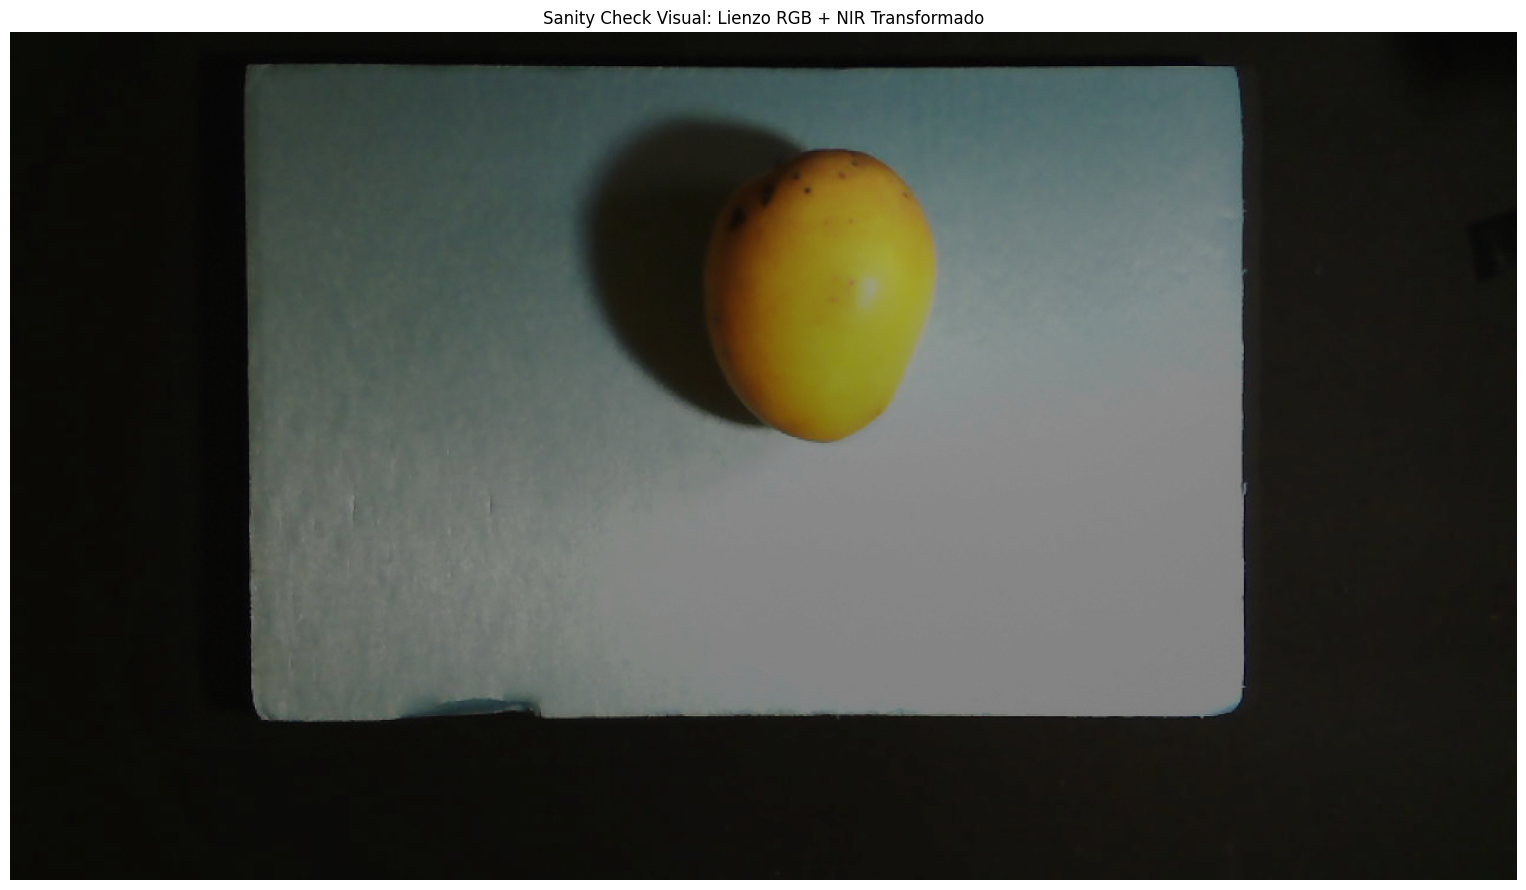

📸 Imagen guardada como 'resultado_fusion_rgb_base.jpg'


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CARGAR DATOS ---
H = np.load('notebooks/matriz_homografia_aruco.npy')

# Rutas de tus imágenes de prueba (asegúrate de que existan)
ruta_rgb = 'notebooks/news_rgb_mango_rgb_1780238376.jpg'
ruta_nir = 'notebooks/news_nir_mango_nir_1780238376.jpg'

img_rgb = cv2.imread(ruta_rgb)
img_nir = cv2.imread(ruta_nir, cv2.IMREAD_GRAYSCALE) # Leemos NIR directo en grises

# Validación rápida
if img_rgb is None or img_nir is None:
    print("❌ Error: No se encontró una de las imágenes. Revisa las rutas.")
else:
    # --- 2. TRANSFORMACIÓN ESPACIAL (WARPING) ---
    # Usamos las dimensiones de la imagen RGB (Nuestro Lienzo Maestro)
    h_rgb, w_rgb = img_rgb.shape[:2]

    # Deformamos la NIR usando H en modo INVERSO para que encaje sobre la RGB
    # Esto evita calcular np.linalg.inv(H) manualmente
    nir_alineada = cv2.warpPerspective(
        img_nir, 
        H, 
        (w_rgb, h_rgb), 
        flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP
    )

    # --- 3. ALPHA BLENDING (FUSIÓN 50/50) ---
    # Convertimos la NIR alineada a BGR (3 canales) para poder mezclarla con la RGB
    nir_color = cv2.cvtColor(nir_alineada, cv2.COLOR_GRAY2BGR)

    # Mezclamos: 50% RGB + 50% NIR
    mezcla = cv2.addWeighted(img_rgb, 0.5, nir_color, 0.5, 0)

    # --- 4. VISUALIZACIÓN EN NOTEBOOK ---
    plt.figure(figsize=(16, 9))
    plt.title("Sanity Check Visual: Lienzo RGB + NIR Transformado")
    plt.imshow(cv2.cvtColor(mezcla, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Guardar en disco para revisión en crudo
    cv2.imwrite('resultado_fusion_rgb_base.jpg', mezcla)
    print("📸 Imagen guardada como 'resultado_fusion_rgb_base.jpg'")